In [1]:
import json

import cmasher as cmr
import gc_utils
import h5py
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
from astropy.stats import biweight_location
from matplotlib import cm
from matplotlib.animation import PillowWriter
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import LogLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d, zoom
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
from scipy.stats import binned_statistic_2d

In [2]:
sim = "m12i"
# group_id = 0
snap_lim = 46

kappa_dict = {
    "m12b": {"kappa_0125": 4.2, "kappa_02": 5.3, "kappa_04": 6.9},
    "m12c": {"kappa_0125": 6.55, "kappa_02": 6.8, "kappa_04": 8.5},
    "m12f": {"kappa_0125": 3.5, "kappa_02": 3.85, "kappa_04": 6.9},
    "m12i": {"kappa_0125": 5.92, "kappa_02": 6.6, "kappa_04": 8.4},
    "m12m": {"kappa_0125": 3.4, "kappa_02": 3.56, "kappa_04": 4.0},
}

# kappa_0125 = kappa_dict[sim]["kappa_0125"]
kappa_02 = kappa_dict[sim]["kappa_02"]
kappa_04 = kappa_dict[sim]["kappa_04"]

# about 2 minutes to run on 101 iterations
it_min = 0
it_max = 100

# tform_bins = 6  # m12b: 8, m12c: 12, m12f: 8, m12i: 6, m12m: 4

In [3]:
sim_dir = "/Users/z5114326/Documents/simulations/"
# sim_dir = "/Volumes/Expansion/simulations/"

pub_data = sim_dir + "snapshot_times_public.txt"
pub_snaps = pd.read_table(pub_data, comment="#", header=None, sep=r"\s+")
pub_snaps.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
snap_lst = pub_snaps["index"].to_numpy()
time_lst = pub_snaps["time_Gyr"].to_numpy()

snap_lst = pub_snaps[pub_snaps["index"] >= snap_lim]["index"].to_numpy()
time_lst = pub_snaps[pub_snaps["index"] >= snap_lim]["time_Gyr"].to_numpy()

all_data = sim_dir + "/" + sim + "/" + sim + "_res7100/" + "snapshot_times.txt"
all_snaps = pd.read_table(all_data, comment="#", header=None, sep=r"\s+")
all_snaps.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]

proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
proc_data = h5py.File(proc_file, "r")  # open processed data file

grp_file = sim_dir + sim + "/" + "gc_groups.json"
with open(grp_file, "r") as file:
    grp_dict = json.load(file)

grp_lst = np.array([int(grp) for grp in grp_dict[sim].keys()])
grp_lst

array([       0,  1920378,  4414957,  8580896, 13687078, 16199669,
       19898495])

In [4]:
grp_lst = grp_lst[grp_lst != 0]
grp_lst

array([ 1920378,  4414957,  8580896, 13687078, 16199669, 19898495])

In [5]:
tacc_lst = []
for grp in grp_lst:
    src_dat = proc_data["it000"]["source"]
    ana_msk = src_dat["analyse_flag"][()] == 1
    grp_msk_src = src_dat["group_id"][()] == grp

    tacc = src_dat["t_acc"][ana_msk & grp_msk_src][0]
    tacc_lst.append(tacc)

tacc_lst

[2.359, 3.608, 5.395, 7.822, 9.148, 11.161]

In [6]:
def get_it_dict(group_id):
    it_dict = {gc_utils.iteration_name(it): {} for it in range(it_min, it_max + 1)}

    for it_id in it_dict.keys():
        src_dat = proc_data[it_id]["source"]
        ana_msk = src_dat["analyse_flag"][()] == 1
        grp_msk_src = src_dat["group_id"][()] == group_id

        snp_dat_600 = proc_data[it_id]["snapshots"]["snap600"]
        grp_msk_600 = snp_dat_600["group_id"][()] == group_id
        gc_sur_lst = snp_dat_600["gc_id"][grp_msk_600]

        gc_dict = {gcid: {} for gcid in gc_sur_lst}
        it_dict[it_id] = gc_dict

    for it_id in it_dict.keys():
        for gcid in it_dict[it_id].keys():
            it_dict[it_id][gcid]["et_norm"] = []
            it_dict[it_id][gcid]["jr"] = []
            it_dict[it_id][gcid]["jp"] = []
            it_dict[it_id][gcid]["jz"] = []

    for it_id in it_dict.keys():
        for snap in snap_lst:
            snap_id = gc_utils.snapshot_name(snap)

            snp_dat = proc_data[it_id]["snapshots"][snap_id]
            acc_msk = snp_dat["now_accreted"][()] == 1
            bnd_msk = snp_dat["bound_flag"][()] == 1
            grp_msk = snp_dat["group_id"][()] == group_id

            gc_snp_lst = snp_dat["gc_id"][acc_msk & bnd_msk & grp_msk]

            for gcid in it_dict[it_id].keys():
                if gcid not in gc_snp_lst:
                    it_dict[it_id][gcid]["et_norm"].append(0)
                    it_dict[it_id][gcid]["jr"].append(0)
                    it_dict[it_id][gcid]["jp"].append(0)
                    it_dict[it_id][gcid]["jz"].append(0)

                else:
                    gcid_idx = np.where(snp_dat["gc_id"][acc_msk & bnd_msk & grp_msk] == gcid)[0][0]
                    et_norm = snp_dat["et_norm"][acc_msk & bnd_msk & grp_msk][gcid_idx]
                    j_cyl = snp_dat["j.cyl"][acc_msk & bnd_msk & grp_msk][gcid_idx]

                    it_dict[it_id][gcid]["et_norm"].append(et_norm)
                    it_dict[it_id][gcid]["jr"].append(j_cyl[0])
                    it_dict[it_id][gcid]["jp"].append(j_cyl[1])
                    it_dict[it_id][gcid]["jz"].append(j_cyl[2])

    for it_id in it_dict.keys():
        for gcid in it_dict[it_id].keys():
            it_dict[it_id][gcid]["det_norm"] = np.diff(it_dict[it_id][gcid]["et_norm"])
            it_dict[it_id][gcid]["djr"] = np.diff(it_dict[it_id][gcid]["jr"])
            it_dict[it_id][gcid]["djp"] = np.diff(it_dict[it_id][gcid]["jp"])
            it_dict[it_id][gcid]["djz"] = np.diff(it_dict[it_id][gcid]["jz"])

            all_zeros = not np.any(it_dict[it_id][gcid]["det_norm"])
            if all_zeros:
                it_dict[it_id][gcid]["det_norm_path"] = np.nan
                it_dict[it_id][gcid]["det_norm_net"] = np.nan

                it_dict[it_id][gcid]["djr_path"] = np.nan
                it_dict[it_id][gcid]["djr_net"] = np.nan

                it_dict[it_id][gcid]["djp_path"] = np.nan
                it_dict[it_id][gcid]["djp_net"] = np.nan

                it_dict[it_id][gcid]["djz_path"] = np.nan
                it_dict[it_id][gcid]["djz_net"] = np.nan

                it_dict[it_id][gcid]["first_term"] = 0
                it_dict[it_id][gcid]["last_term"] = 0
                continue

            first_term_idx = np.min(np.nonzero(it_dict[it_id][gcid]["et_norm"]))
            last_term_idx = np.max(np.nonzero(it_dict[it_id][gcid]["et_norm"]))

            it_dict[it_id][gcid]["det_norm"][first_term_idx - 1] = 0
            it_dict[it_id][gcid]["djr"][first_term_idx - 1] = 0
            it_dict[it_id][gcid]["djp"][first_term_idx - 1] = 0
            it_dict[it_id][gcid]["djz"][first_term_idx - 1] = 0

            # if GC does not survive to z = 0
            # this just here as an ensurance as by selection they survive to z = 0
            if last_term_idx < len(it_dict[it_id][gcid]["det_norm"]) - 1:
                it_dict[it_id][gcid]["det_norm"][last_term_idx] = 0
                it_dict[it_id][gcid]["djr"][last_term_idx] = 0
                it_dict[it_id][gcid]["djp"][last_term_idx] = 0
                it_dict[it_id][gcid]["djz"][last_term_idx] = 0

            det_norm_net = (
                it_dict[it_id][gcid]["et_norm"][last_term_idx]
                - it_dict[it_id][gcid]["et_norm"][first_term_idx]
            )
            djr_net = it_dict[it_id][gcid]["jr"][last_term_idx] - it_dict[it_id][gcid]["jr"][first_term_idx]
            djp_net = it_dict[it_id][gcid]["jp"][last_term_idx] - it_dict[it_id][gcid]["jp"][first_term_idx]
            djz_net = it_dict[it_id][gcid]["jz"][last_term_idx] - it_dict[it_id][gcid]["jz"][first_term_idx]

            it_dict[it_id][gcid]["det_norm_path"] = np.sum(np.abs(it_dict[it_id][gcid]["det_norm"]))
            it_dict[it_id][gcid]["det_norm_net"] = np.abs(det_norm_net)

            it_dict[it_id][gcid]["djr_path"] = np.sum(np.abs(it_dict[it_id][gcid]["djr"]))
            it_dict[it_id][gcid]["djr_net"] = np.abs(djr_net)

            it_dict[it_id][gcid]["djp_path"] = np.sum(np.abs(it_dict[it_id][gcid]["djp"]))
            it_dict[it_id][gcid]["djp_net"] = np.abs(djp_net)

            it_dict[it_id][gcid]["djz_path"] = np.sum(np.abs(it_dict[it_id][gcid]["djz"]))
            it_dict[it_id][gcid]["djz_net"] = np.abs(djz_net)

            it_dict[it_id][gcid]["first_term"] = first_term_idx
            it_dict[it_id][gcid]["last_term"] = last_term_idx

    return it_dict

In [7]:
it_dict_lst = []
for grp in grp_lst:
    it_dict = get_it_dict(grp)
    it_dict_lst.append(it_dict)

(0.0, 1.0)

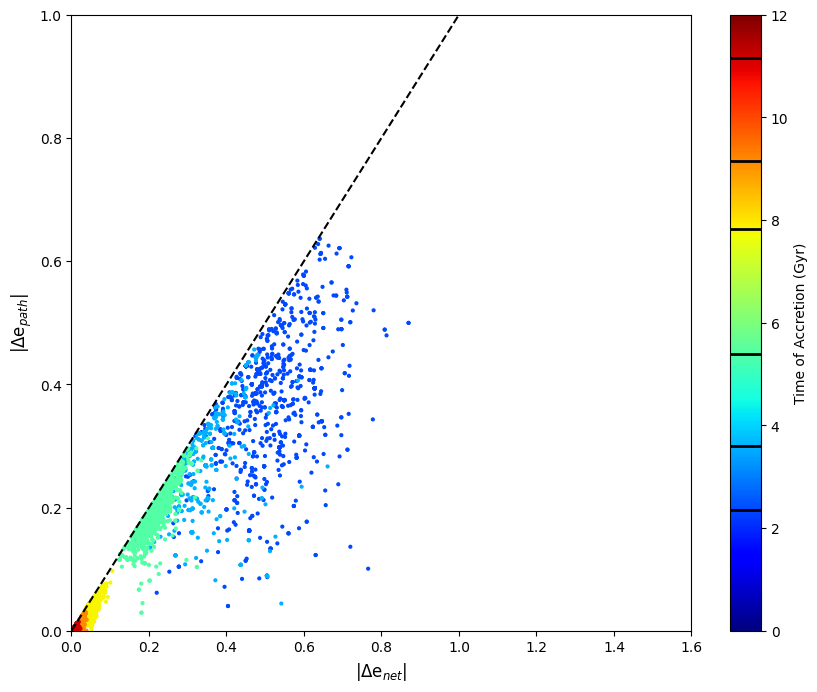

In [ ]:
var = "et_norm"

var_dict = {
    "et_norm": {
        "xlab": r"|$\Delta$e$_{net}|$",
        "ylab": r"|$\Delta$e$_{path}|$",
        "xlim": 0.8,
        "ylim": 1,
    },
    "jr": {
        "xlab": r"|$\Delta$J$_{r, net}$| (kpc km s$^{-1}$)",
        "ylab": r"|$\Delta$J$_{r, path}$| (kpc km s$^{-1}$)",
        "xlim": 3000,
        "ylim": 6000,
    },
    "jp": {
        "xlab": r"|$\Delta J_{\phi,\ \mathrm{net}}$| (kpc km s$^{-1}$)",
        "ylab": r"|$\Delta J_{\phi,\ \mathrm{path}}$| (kpc km s$^{-1}$)",
        "xlim": 6000,
        "ylim": 12000,
    },
    "jz": {
        "xlab": r"|$\Delta$J$_{z, net}$| (kpc km s$^{-1}$)",
        "ylab": r"|$\Delta$J$_{z, path}$$ (kpc km s$^{-1}$)",
        "xlim": 3000,
        "ylim": 10000,
    },
}

cmap = "jet"
vmin = 0
vmax = 12

fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=False, sharex=False)
for i, _ in enumerate(grp_lst):
    it_dict = it_dict_lst[i]
    tacc = tacc_lst[i]
    for it_id in it_dict:
        x_lst = []
        y_lst = []
        c_lst = []
        for gcid in it_dict[it_id]:
            x_lst.append(it_dict[it_id][gcid]["d" + var + "_net"])
            y_lst.append(it_dict[it_id][gcid]["d" + var + "_path"])
            c_lst.append(tacc)

        sc = ax.scatter(y_lst, x_lst, c=c_lst, s=4, cmap=cmap, vmin=vmin, vmax=vmax)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Time of Accretion (Gyr)")

for tacc in tacc_lst:
    cbar.ax.hlines(tacc, xmin=0, xmax=1, colors="k", linewidth=2)

kappa_02 = 6.6
kappa_04 = 8.4
# cbar.ax.hlines(kappa_02, xmin=0, xmax=1, colors="r", linewidth=2)
# cbar.ax.hlines(kappa_04, xmin=0, xmax=1, colors="r", linewidth=2)


xlim = var_dict[var]["xlim"]
ylim = var_dict[var]["ylim"]

max_val = np.max([xlim, ylim])

ax.plot([0, max_val], [0, max_val], c="k", ls="--")
ax.set_xlabel(var_dict[var]["xlab"], fontsize=12)
ax.set_ylabel(var_dict[var]["ylab"], fontsize=12)

ax.set_xlim([0, xlim])
ax.set_ylim([0, ylim])

In [32]:
def get_z(ax, it_dict, var, col="b", xlim=(0, 2000), ylim=(0, 5000), grid_size=200, level_lim=75):
    all_Z = []
    for it_id in it_dict:
        centroid_lst = []
        net_lst = []
        path_lst = []

        if len(it_dict[it_id]) <= 2:
            continue

        for gcid in it_dict[it_id]:
            centroid_lst.append(it_dict[it_id][gcid][var][-1])
            net_lst.append(it_dict[it_id][gcid]["d" + var + "_net"])
            path_lst.append(it_dict[it_id][gcid]["d" + var + "_path"])
        # centroid_lst = np.array(centroid_lst)
        # centroid = np.average(centroid_lst)
        # centroid_dist = np.abs(centroid - centroid_lst)
        # centroid_dist = centroid - centroid_lst

        net_lst = np.array(net_lst)
        path_lst = np.array(path_lst)

        x = net_lst
        y = path_lst

        xy = np.vstack([x, y])
        kde = stats.gaussian_kde(xy)

        xmin, xmax = xlim
        ymin, ymax = ylim
        X, Y = np.mgrid[xmin:xmax:grid_size, ymin:ymax:grid_size]
        positions = np.vstack([X.ravel(), Y.ravel()])
        Z = np.reshape(kde(positions).T, X.shape)
        all_Z.append(Z)

    Z_mean = np.mean(all_Z, axis=0)

    Z_sort = np.sort(Z_mean.ravel())[::-1]
    cumsum = np.cumsum(Z_sort)
    cumsum /= cumsum[-1]
    level_lim = level_lim / 100
    level = Z_sort[np.searchsorted(cumsum, level_lim)]  # 75% level

    ax.contour(X, Y, Z_mean, levels=[level], colors=col)

    return Z_mean

(0.0, 6500.0)

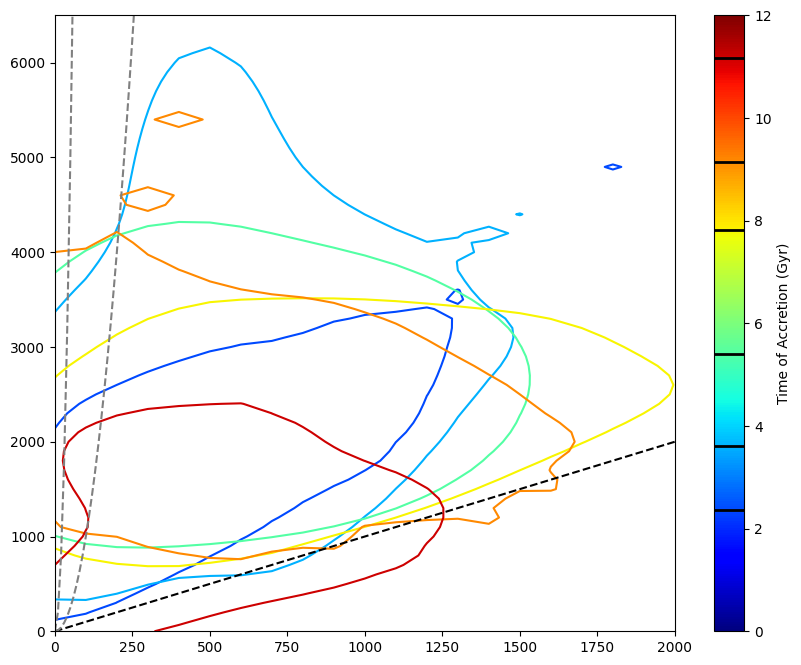

In [92]:
var = "jr"


var_dict = {
    "et_norm": {
        "xlab": r"|$\Delta$e$_{net}|$",
        "ylab": r"|$\Delta$e$_{path}|$",
        "xlim": 1,
        "ylim": 1,
    },
    "jr": {
        "xlab": r"|$\Delta$J$_{r, net}$| (kpc km s$^{-1}$)",
        "ylab": r"|$\Delta$J$_{r, path}$| (kpc km s$^{-1}$)",
        "xlim": 10000,
        "ylim": 10000,
    },
    "jp": {
        "xlab": r"|$\Delta J_{\phi,\ \mathrm{net}}$| (kpc km s$^{-1}$)",
        "ylab": r"|$\Delta J_{\phi,\ \mathrm{path}}$| (kpc km s$^{-1}$)",
        "xlim": 10000,
        "ylim": 10000,
    },
    "jz": {
        "xlab": r"|$\Delta$J$_{z, net}$| (kpc km s$^{-1}$)",
        "ylab": r"|$\Delta$J$_{z, path}$$ (kpc km s$^{-1}$)",
        "xlim": 10000,
        "ylim": 10000,
    },
}

xlim = (0, var_dict[var]["xlim"])
ylim = (0, var_dict[var]["ylim"])

cmap = plt.colormaps["jet"]
vmin = 0
vmax = 12

fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=False, sharex=False)

for i, _ in enumerate(grp_lst):
    it_dict = it_dict_lst[i]
    tacc = tacc_lst[i]

    # Map tacc to RGBA color
    norm_tacc = np.clip((tacc - vmin) / (vmax - vmin), 0, 1)  # ensure in [0,1]
    col = cmap(norm_tacc)  # returns RGBA tuple

    # Ensure contour gets a list
    z_avg = get_z(ax, it_dict, var, [col], xlim, ylim, 100, 75)

# Add colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Time of Accretion (Gyr)")

for tacc in tacc_lst:
    cbar.ax.hlines(tacc, xmin=0, xmax=1, colors="k", linewidth=2)

max_val = np.max([xlim, ylim])
ax.plot([0, max_val], [0, max_val], c="k", ls="--")

# Mock net migration values (kpc)
net = np.arange(0, 1000, 10)

# Define k boundaries
k_coherent = 0.1
k_diff_high = 2.0

# Corresponding path migration parabolas
path_coherent = k_coherent * net**2
path_diff_high = k_diff_high * net**2

plt.plot(net, path_coherent, color="grey", linestyle="--", label="k=0.5 boundary")
plt.plot(net, path_diff_high, color="grey", linestyle="--", label="k=2 boundary")

plt.xlim(0, 2000)
plt.ylim(0, 6500)

# IGNORE

In [ ]:
def get_it_dict_in(group_id):
    it_dict = {gc_utils.iteration_name(it): {} for it in range(it_min, it_max + 1)}

    for it_id in it_dict.keys():
        src_dat = proc_data[it_id]["source"]
        ana_msk = src_dat["analyse_flag"][()] == 1
        grp_msk_src = src_dat["group_id"][()] == group_id

        snp_dat_600 = proc_data[it_id]["snapshots"]["snap600"]
        grp_msk_600 = snp_dat_600["group_id"][()] == group_id
        gc_sur_lst = snp_dat_600["gc_id"][grp_msk_600]

        gc_dict = {gcid: {} for gcid in gc_sur_lst}

        for gcid in gc_dict.keys():
            gcid_idx = np.where(src_dat["gc_id"][ana_msk & grp_msk_src] == gcid)[0][0]
            if group_id == 0:
                tform = src_dat["form_time"][ana_msk & grp_msk_src][gcid_idx]
            else:
                tform = src_dat["t_acc"][ana_msk & grp_msk_src][gcid_idx]
            gc_dict[gcid]["tform"] = tform

        it_dict[it_id] = gc_dict

    for it_id in it_dict.keys():
        for gcid in it_dict[it_id].keys():
            it_dict[it_id][gcid]["et_norm"] = []
            it_dict[it_id][gcid]["jr"] = []
            it_dict[it_id][gcid]["jp"] = []
            it_dict[it_id][gcid]["jz"] = []
            it_dict[it_id][gcid]["r"] = []
            it_dict[it_id][gcid]["p"] = []
            it_dict[it_id][gcid]["z"] = []

    for it_id in it_dict.keys():
        for snap in snap_lst:
            snap_id = gc_utils.snapshot_name(snap)

            snp_dat = proc_data[it_id]["snapshots"][snap_id]
            acc_msk = snp_dat["now_accreted"][()] == 1
            bnd_msk = snp_dat["bound_flag"][()] == 1
            grp_msk = snp_dat["group_id"][()] == group_id

            gc_snp_lst = snp_dat["gc_id"][acc_msk & bnd_msk & grp_msk]

            for gcid in it_dict[it_id].keys():
                if gcid not in gc_snp_lst:
                    it_dict[it_id][gcid]["et_norm"].append(0)
                    it_dict[it_id][gcid]["jr"].append(0)
                    it_dict[it_id][gcid]["jp"].append(0)
                    it_dict[it_id][gcid]["jz"].append(0)
                    it_dict[it_id][gcid]["r"].append(0)
                    it_dict[it_id][gcid]["p"].append(0)
                    it_dict[it_id][gcid]["z"].append(0)

                else:
                    gcid_idx = np.where(snp_dat["gc_id"][acc_msk & bnd_msk & grp_msk] == gcid)[0][0]
                    et_norm = snp_dat["et_norm"][acc_msk & bnd_msk & grp_msk][gcid_idx]
                    j_cyl = snp_dat["j.cyl"][acc_msk & bnd_msk & grp_msk][gcid_idx]
                    pos_cyl = snp_dat["pos.cyl"][acc_msk & bnd_msk & grp_msk][gcid_idx]

                    it_dict[it_id][gcid]["et_norm"].append(et_norm)
                    it_dict[it_id][gcid]["jr"].append(j_cyl[0])
                    it_dict[it_id][gcid]["jp"].append(j_cyl[1])
                    it_dict[it_id][gcid]["jz"].append(j_cyl[2])

                    it_dict[it_id][gcid]["r"].append(pos_cyl[0])
                    it_dict[it_id][gcid]["p"].append(pos_cyl[1])
                    it_dict[it_id][gcid]["z"].append(pos_cyl[2])

    for it_id in it_dict.keys():
        for gcid in it_dict[it_id].keys():
            it_dict[it_id][gcid]["det_norm"] = np.diff(it_dict[it_id][gcid]["et_norm"])
            it_dict[it_id][gcid]["djr"] = np.diff(it_dict[it_id][gcid]["jr"])
            it_dict[it_id][gcid]["djp"] = np.diff(it_dict[it_id][gcid]["jp"])
            it_dict[it_id][gcid]["djz"] = np.diff(it_dict[it_id][gcid]["jz"])

            all_zeros = not np.any(it_dict[it_id][gcid]["det_norm"])
            if all_zeros:
                it_dict[it_id][gcid]["det_norm_path"] = np.nan
                it_dict[it_id][gcid]["det_norm_net"] = np.nan

                it_dict[it_id][gcid]["djr_path"] = np.nan
                it_dict[it_id][gcid]["djr_net"] = np.nan

                it_dict[it_id][gcid]["djp_path"] = np.nan
                it_dict[it_id][gcid]["djp_net"] = np.nan

                it_dict[it_id][gcid]["djz_path"] = np.nan
                it_dict[it_id][gcid]["djz_net"] = np.nan

                it_dict[it_id][gcid]["first_term"] = 0
                it_dict[it_id][gcid]["last_term"] = 0
                continue

            first_term_idx = np.min(np.nonzero(it_dict[it_id][gcid]["et_norm"]))
            last_term_idx = np.max(np.nonzero(it_dict[it_id][gcid]["et_norm"]))

            it_dict[it_id][gcid]["det_norm"][first_term_idx - 1] = 0
            it_dict[it_id][gcid]["djr"][first_term_idx - 1] = 0
            it_dict[it_id][gcid]["djp"][first_term_idx - 1] = 0
            it_dict[it_id][gcid]["djz"][first_term_idx - 1] = 0

            # if GC does not survive to z = 0
            # this just here as an ensurance as by selection they survive to z = 0
            if last_term_idx < len(it_dict[it_id][gcid]["det_norm"]) - 1:
                it_dict[it_id][gcid]["det_norm"][last_term_idx] = 0
                it_dict[it_id][gcid]["djr"][last_term_idx] = 0
                it_dict[it_id][gcid]["djp"][last_term_idx] = 0
                it_dict[it_id][gcid]["djz"][last_term_idx] = 0

            det_norm_net = (
                it_dict[it_id][gcid]["et_norm"][last_term_idx]
                - it_dict[it_id][gcid]["et_norm"][first_term_idx]
            )
            djr_net = it_dict[it_id][gcid]["jr"][last_term_idx] - it_dict[it_id][gcid]["jr"][first_term_idx]
            djp_net = it_dict[it_id][gcid]["jp"][last_term_idx] - it_dict[it_id][gcid]["jp"][first_term_idx]
            djz_net = it_dict[it_id][gcid]["jz"][last_term_idx] - it_dict[it_id][gcid]["jz"][first_term_idx]

            it_dict[it_id][gcid]["det_norm_path"] = np.sum(np.abs(it_dict[it_id][gcid]["det_norm"]))
            it_dict[it_id][gcid]["det_norm_net"] = np.abs(det_norm_net)

            it_dict[it_id][gcid]["djr_path"] = np.sum(np.abs(it_dict[it_id][gcid]["djr"]))
            it_dict[it_id][gcid]["djr_net"] = np.abs(djr_net)

            it_dict[it_id][gcid]["djp_path"] = np.sum(np.abs(it_dict[it_id][gcid]["djp"]))
            it_dict[it_id][gcid]["djp_net"] = np.abs(djp_net)

            it_dict[it_id][gcid]["djz_path"] = np.sum(np.abs(it_dict[it_id][gcid]["djz"]))
            it_dict[it_id][gcid]["djz_net"] = np.abs(djz_net)

            it_dict[it_id][gcid]["first_term"] = first_term_idx
            it_dict[it_id][gcid]["last_term"] = last_term_idx

    return it_dict

In [ ]:
group_id = 0

insitu_it_dict = get_it_dict_in(group_id)

In [ ]:
it_dict = insitu_it_dict

(2.0, 13.798746883)

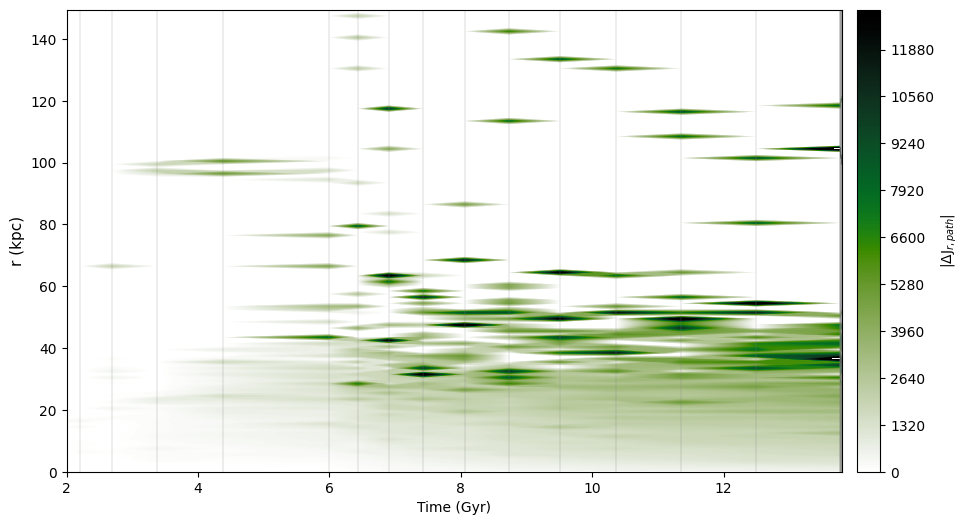

In [ ]:
var = "jr"
pos = "r"

var_dict = {
    "et_norm": {"d_max": 150, "d_bin": 1, "vmax": 1, "vsize": 0.05, "label": r"|$\Delta$e$_{path}$|"},
    "jr": {"d_max": 150, "d_bin": 1, "vmax": 13000, "vsize": 20, "label": r"|$\Delta$J$_{r, path}$|"},
    "jp": {"d_max": 150, "d_bin": 5, "vmax": 0.2, "vsize": 0.01, "label": r"|$\Delta$J$_{p, path}$|"},
    "jz": {"d_max": 150, "d_bin": 5, "vmax": 0.3, "vsize": 0.01, "label": r"|$\Delta$J$_{z, path}$|"},
}

d_max = var_dict[var]["d_max"]

# --- SETUP ---
n_snaps = len(pub_snaps[pub_snaps["index"] >= snap_lim])  # number of snapshots >= snap_lim
d_bin_size = var_dict[var]["d_bin"]
d_bins = np.arange(0, d_max + d_bin_size, d_bin_size)
d_centres_in = 0.5 * (d_bins[:-1] + d_bins[1:])
d_bin_num = len(d_bins) - 1

# Arrays to store normalized counts per bin
d_bin_cnt = np.zeros((n_snaps, d_bin_num))

# Loop through snapshots
k = 0
for i, snap in enumerate(snap_lst):
    snap_id = gc_utils.snapshot_name(snap)
    time = pub_snaps[pub_snaps["index"] == snap]["time_Gyr"].values[0]

    # --- COLLECT dvar for ALL GCs alive at this time ---
    val_lst = []
    d_path_lst = []
    for it_id in it_dict:
        for gcid in it_dict[it_id]:
            if it_dict[it_id][gcid]["tform"] <= time:
                val = it_dict[it_id][gcid][pos][i]
                val_lst.append(val)

                d_arr = it_dict[it_id][gcid]["d" + var]
                d_val = np.nansum(np.abs(d_arr[: i - 1])) if i >= 2 else 0.0
                d_path_lst.append(d_val)

    val_lst = np.array(val_lst)
    d_path_lst = np.array(d_path_lst)

    # --- BINNING ---
    for j in range(d_bin_num):
        d_min = d_bins[j]
        d_max = d_bins[j + 1]

        d_msk = (val_lst >= d_min) & (val_lst < d_max)
        z_msk = val_lst != 0  # optional: exclude zero change
        d_avg = np.average(d_path_lst[d_msk & z_msk])

        if d_avg > 0:
            d_bin_cnt[k, j] = d_avg

    k += 1

# --- PLOTTING ---
x = pub_snaps[pub_snaps["index"] >= snap_lim]["time_Gyr"].to_numpy()
y = d_centres_in
vmin = 0
vmax = var_dict[var]["vmax"]
vsize = var_dict[var]["vsize"]
cmap = cmr.jungle_r
levels = np.arange(vmin, vmax + vsize, vsize)

fig, ax = plt.subplots(figsize=(10, 6))
contour_mig = ax.contourf(x, y, d_bin_cnt.T, cmap=cmap, levels=levels)

# Colorbar
cax = inset_axes(
    ax,
    width="3%",
    height="100%",
    loc="center right",
    bbox_to_anchor=(0.05, 0, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0,
)
cbar = fig.colorbar(contour_mig, cax=cax, orientation="vertical", label=var_dict[var]["label"])
cbar.update_ticks()

# Labels
ax.set_xlabel("Time (Gyr)", fontsize=10)
ax.set_ylabel(pos + " (kpc)", fontsize=11)

# Vertical time lines
for xi in x:
    ax.plot([xi, xi], [-d_max, d_max], c="grey", lw=0.2)

ax.set_ylim(0, d_max - d_bin_size / 2)

ax.set_xlim(2, np.max(x))